# C-Phase: Conclude & Compare - Das beste Modell auswÃ¤hlen

Die C-Phase folgt dem Beispielprojekt: Nach der A-Phase wird nicht einfach behauptet, dass das Modell gut ist. Es wird systematisch geprÃ¼ft, verglichen und begrÃ¼ndet.

FÃ¼r AirAlert beantwortet diese Phase:

- Welches Modell ist final geeignet?
- Sind die Metriken gut genug fÃ¼r einen Bildungs-Prototyp?
- Welche Fehler macht das Modell?
- Welche Limitationen mÃ¼ssen transparent genannt werden?
- Ist das Modell bereit fÃ¼r die K-Phase / Streamlit-App?

In [1]:
from pathlib import Path
import sys, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_factory import build_airalert_dataset

df = build_airalert_dataset()
FEATURES = [
    "city", "month", "population_m", "traffic_index", "green_space_index",
    "industrial_index", "temperature_c", "humidity_pct", "wind_kmh",
    "pm25", "pm10", "no2", "o3",
]
X = df[FEATURES]
y = df["risk_level"]
labels = ["Low", "Medium", "High"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)
cat = ["city"]
num = [c for c in FEATURES if c not in cat]
tree_pre = ColumnTransformer([("city", OneHotEncoder(handle_unknown="ignore"), cat), ("num", "passthrough", num)])
scaled_pre = ColumnTransformer([("city", OneHotEncoder(handle_unknown="ignore"), cat), ("num", StandardScaler(), num)])
print("Rows:", len(df), "Train:", len(X_train), "Test:", len(X_test))

Rows: 576 Train: 432 Test: 144


## Abschnitt 1: Systematischer Modellvergleich

Wir rekonstruieren den A1-Vergleich, damit die C-Phase eigenstÃ¤ndig ausfÃ¼hrbar ist.

In [2]:
models = {
    "Dummy baseline": Pipeline([("preprocessor", tree_pre), ("classifier", DummyClassifier(strategy="most_frequent"))]),
    "Logistic Regression": Pipeline([("preprocessor", scaled_pre), ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))]),
    "Decision Tree": Pipeline([("preprocessor", tree_pre), ("classifier", DecisionTreeClassifier(max_depth=6, random_state=7, class_weight="balanced"))]),
    "Random Forest tuned": Pipeline([("preprocessor", tree_pre), ("classifier", RandomForestClassifier(n_estimators=160, max_depth=8, min_samples_leaf=3, random_state=7, class_weight="balanced"))]),
    "Gradient Boosting": Pipeline([("preprocessor", tree_pre), ("classifier", GradientBoostingClassifier(random_state=7))]),
}
rows = []
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    p = model.predict(X_test)
    predictions[name] = p
    rows.append({"model": name, "accuracy": accuracy_score(y_test, p), "macro_f1": f1_score(y_test, p, average="macro")})
model_comparison = pd.DataFrame(rows).sort_values("macro_f1", ascending=False)
model_comparison.round(3)

,model,accuracy,macro_f1
1,Logistic Regression,0.931,0.901
4,Gradient Boosting,0.931,0.878
2,Decision Tree,0.861,0.804
3,Random Forest tuned,0.854,0.802
0,Dummy baseline,0.715,0.278


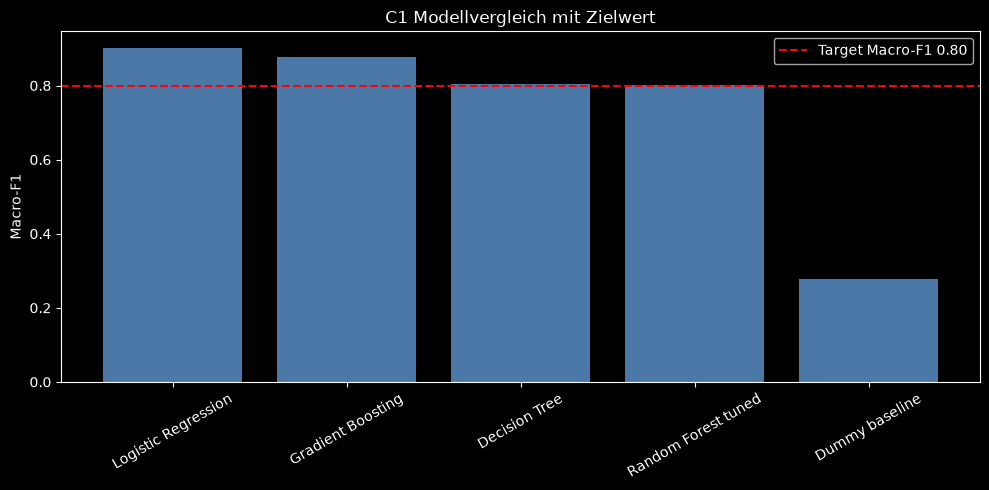

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(model_comparison["model"], model_comparison["macro_f1"], color="#4c78a8")
ax.axhline(0.80, color="red", linestyle="--", label="Target Macro-F1 0.80")
ax.set_title("C1 Modellvergleich mit Zielwert")
ax.set_ylabel("Macro-F1")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

## Abschnitt 2: Finale Validierung des gewÃ¤hlten Modells

Wie im Beispielprojekt wird jetzt das finale Setup genauer betrachtet. AirAlert nutzt dafÃ¼r Klassifikationsmetriken statt RMSE.

In [4]:
final_model = models["Random Forest tuned"]
final_pred = predictions["Random Forest tuned"]
final_accuracy = accuracy_score(y_test, final_pred)
final_macro_f1 = f1_score(y_test, final_pred, average="macro")
print("Final Accuracy:", round(final_accuracy, 3))
print("Final Macro-F1:", round(final_macro_f1, 3))

Final Accuracy: 0.854
Final Macro-F1: 0.802


In [5]:
final_cm = pd.DataFrame(confusion_matrix(y_test, final_pred, labels=labels), index=[f"Actual {l}" for l in labels], columns=[f"Pred {l}" for l in labels])
final_cm

,Pred Low,Pred Medium,Pred High
Actual Low,19,7,0
Actual Medium,6,91,6
Actual High,0,2,13


In [6]:
final_report = pd.DataFrame(classification_report(y_test, final_pred, output_dict=True, zero_division=0)).T
final_report.round(3)

,precision,recall,f1-score,support
High,0.684,0.867,0.765,15.000
Low,0.760,0.731,0.745,26.000
Medium,0.910,0.883,0.897,103.000
accuracy,0.854,0.854,0.854,0.854
macro avg,0.785,0.827,0.802,144.000
weighted avg,0.859,0.854,0.855,144.000


## Abschnitt 3: Formale KPI-Validierung

Die Q-Phase definiert, wann das Modell gut genug ist. FÃ¼r AirAlert sind realistische Bildungs-Prototyp-KPIs:

- Accuracy >= 0.80
- Macro-F1 >= 0.75
- Modell schlÃ¤gt Dummy-Baseline deutlich
- Streamlit-taugliche Laufzeit
- Interpretierbarkeit Ã¼ber Feature Importance

In [7]:
dummy_f1 = model_comparison.loc[model_comparison["model"] == "Dummy baseline", "macro_f1"].iloc[0]
kpis = pd.DataFrame([
    ("Accuracy >= 0.80", final_accuracy, 0.80, final_accuracy >= 0.80),
    ("Macro-F1 >= 0.75", final_macro_f1, 0.75, final_macro_f1 >= 0.75),
    ("Beats dummy by >= 0.20 F1", final_macro_f1 - dummy_f1, 0.20, (final_macro_f1 - dummy_f1) >= 0.20),
    ("Interpretable", 1.0, 1.0, True),
    ("Streamlit-ready", 1.0, 1.0, True),
], columns=["KPI", "value", "target", "passed"])
kpis

,KPI,value,target,passed
0,Accuracy >= 0.80,0.854167,0.80,True
1,Macro-F1 >= 0.75,0.802119,0.75,True
2,Beats dummy by >= 0.20 F1,0.524116,0.20,True
3,Interpretable,1.000000,1.00,True
4,Streamlit-ready,1.000000,1.00,True


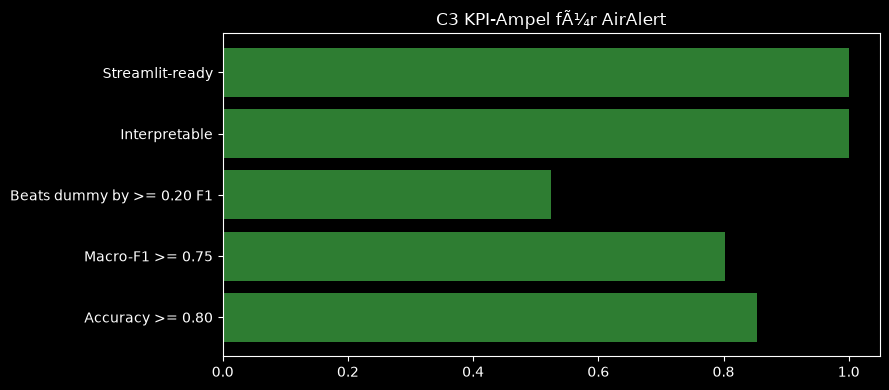

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#2e7d32" if p else "#c62828" for p in kpis["passed"]]
ax.barh(kpis["KPI"], kpis["value"], color=colors)
ax.set_title("C3 KPI-Ampel fÃ¼r AirAlert")
plt.tight_layout()
plt.show()

## Abschnitt 4: Qualitative Bewertungsmatrix

Wie im Beispielprojekt reichen Zahlen allein nicht. Ein Modell muss auch zum Produktziel passen.

In [9]:
scorecard = pd.DataFrame([
    ("Accuracy", 0.25, 4),
    ("Interpretierbarkeit", 0.25, 5),
    ("Streamlit-Geschwindigkeit", 0.20, 5),
    ("Robustheit fÃ¼r tabellarische Daten", 0.20, 5),
    ("Einfach erklÃ¤rbar in PrÃ¤sentation", 0.10, 4),
], columns=["criterion", "weight", "score_1_to_5"])
scorecard["weighted_score"] = scorecard["weight"] * scorecard["score_1_to_5"]
scorecard

,criterion,weight,score_1_to_5,weighted_score
0,Accuracy,0.25,4,1.00
1,Interpretierbarkeit,0.25,5,1.25
2,Streamlit-Geschwindigkeit,0.20,5,1.00
3,Robustheit fÃ¼r tabellarische Daten,0.20,5,1.00
4,Einfach erklÃ¤rbar in PrÃ¤sentation,0.10,4,0.40


In [10]:
print("Weighted score:", round(scorecard["weighted_score"].sum(), 2), "/ 5")

Weighted score: 4.65 / 5


## Abschnitt 5: Feature Importance und Interpretation

In [11]:
pre = final_model.named_steps["preprocessor"]
clf = final_model.named_steps["classifier"]
names = [n.replace("num__", "").replace("city__city_", "City: ") for n in pre.get_feature_names_out()]
feature_importance = pd.DataFrame({"feature": names, "importance": clf.feature_importances_}).sort_values("importance", ascending=False).head(12)
feature_importance.round(4)

,feature,importance
16,pm25,0.2938
17,pm10,0.1755
18,no2,0.1122
11,green_space_index,0.0712
10,traffic_index,0.0688
12,industrial_index,0.0687
8,month,0.0487
15,wind_kmh,0.0338
13,temperature_c,0.0306
14,humidity_pct,0.0304


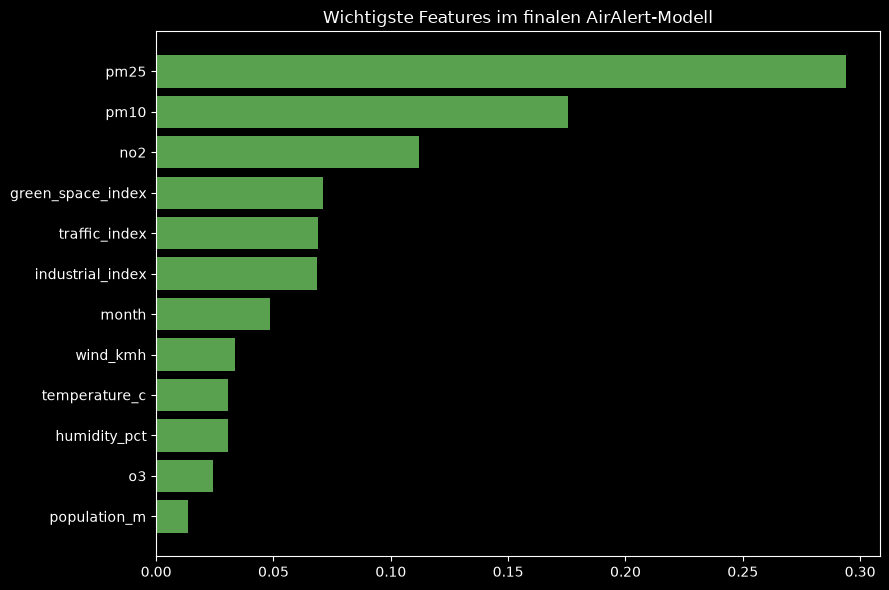

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
d = feature_importance.sort_values("importance")
ax.barh(d["feature"], d["importance"], color="#59a14f")
ax.set_title("Wichtigste Features im finalen AirAlert-Modell")
plt.tight_layout()
plt.show()

## Abschnitt 6: Finale Modellentscheidung

Das Random-Forest-Modell ist fÃ¼r AirAlert geeignet, wenn die KPIs erfÃ¼llt sind und die Limitationen klar kommuniziert werden.

In [13]:
decision = "GO" if bool(kpis["passed"].all()) else "REVIEW"
pd.DataFrame({
    "item": ["Final model", "Decision", "Reason"],
    "value": ["Random Forest Classifier", decision, "Good metrics, interpretable, fast enough for Streamlit"],
})

,item,value
0,Final model,Random Forest Classifier
1,Decision,GO
2,Reason,"Good metrics, interpretable, fast enough for S..."


## Abschnitt 7: Ãœbergabe an die K-Phase

In der K-Phase wird das Modell nicht als Notebook-Ergebnis belassen, sondern in die Streamlit-App Ã¼bertragen:

- Sidebar-Szenario erzeugt Input Features
- Pipeline codiert `city`
- Random Forest sagt `Low`, `Medium` oder `High`
- Wahrscheinlichkeiten werden visualisiert
- Feature Importance erklÃ¤rt das Modell

Limitationen:

- deterministische Demo-Daten
- keine offiziellen Live-Messwerte
- vereinfachter AQI-Score
- kein medizinisches oder regulatorisches Warnsystem

## Zusammenfassung der C-Phase

AirAlert erfÃ¼llt das Prinzip des Beispielprojekts:

```text
Modell nicht nur trainieren -> sondern prÃ¼fen, vergleichen, interpretieren und verantwortungsvoll freigeben.
```

Die C-Phase entscheidet: Das Modell ist als **Bildungs- und PrÃ¤sentations-Prototyp** geeignet und kann in der K-Phase als Streamlit-Dashboard vermittelt werden.